In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from itertools import permutations,combinations

In [2]:
with open("../../Data/disease_to_snomed_id.json", "r") as file:
    disease_to_snomed_id = json.load(file)

In [3]:
LIST_OF_DISEASES = list(disease_to_snomed_id.keys())

In [4]:
LIST_OF_DISEASES

['BIPOLAR',
 'SCHIZOPHRENIA',
 'LEUKEMIA',
 'PARKINSON',
 'DIABETES',
 'BREASTCANCER']

In [5]:
with open("../output/disease_to_comm_dgidb_gene_count.json", "r") as f:
    disease_to_comm_dgidb_gene_count = json.load(f)

In [6]:
# Convert index to integers
for d in disease_to_comm_dgidb_gene_count.keys():
    disease_to_comm_dgidb_gene_count[d] = {int(k): v for k, v in disease_to_comm_dgidb_gene_count[d].items()}

In [7]:
disease_to_comm_dgidb_gene_count

{'BIPOLAR': {0: 25, 1: 0, 2: 3, 3: 5, 4: 0, 5: 1, 6: 60, 7: 0, 8: 1, 9: 0},
 'SCHIZOPHRENIA': {0: 2,
  1: 1,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 7,
  7: 51,
  8: 0,
  9: 6,
  10: 0},
 'LEUKEMIA': {0: 4,
  1: 5,
  2: 0,
  3: 26,
  4: 0,
  5: 0,
  6: 4,
  7: 3,
  8: 10,
  9: 0,
  10: 0},
 'BREASTCANCER': {0: 0,
  1: 7,
  2: 75,
  3: 2,
  4: 0,
  5: 0,
  6: 4,
  7: 4,
  8: 0,
  9: 1,
  10: 1,
  11: 0},
 'PARKINSON': {0: 1,
  1: 0,
  2: 0,
  3: 14,
  4: 0,
  5: 0,
  6: 1,
  7: 14,
  8: 0,
  9: 0,
  10: 0},
 'DIABETES': {0: 1,
  1: 0,
  2: 0,
  3: 6,
  4: 0,
  5: 0,
  6: 1,
  7: 3,
  8: 0,
  9: 0,
  10: 0}}

In [8]:
def jaccard(A, B):
    """
    Compute Jaccard similarity between two iterables.
    """
    A = set(A)
    B = set(B)

    if not A and not B:
        return 0.0

    return len(A & B) / len(A | B)

In [9]:
def jaccard_matrix(communities_left, communities_right):
    """
    Compute Jaccard similarity matrix between two lists of communities.

    Rows correspond to communities_left,
    columns correspond to communities_right.
    """
    J = np.zeros((len(communities_left), len(communities_right)), dtype=float)

    for i, A in enumerate(communities_left):
        for j, B in enumerate(communities_right):
            J[i, j] = jaccard(A, B)

    return J

In [10]:
def plot_heatmap(M, row_labels=None, col_labels=None,
                 cmap="viridis", vmin=None, vmax=None, save_path=None):
    """
    Plot a heatmap for a 2D matrix, with optional row/column labels,
    and show the value in each cell.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    M = np.asarray(M)

    plt.figure()
    im = plt.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    plt.colorbar(im)

    # Optional labels
    if row_labels is not None:
        plt.yticks(range(len(row_labels)), row_labels)
    else:
        plt.yticks([])

    if col_labels is not None:
        plt.xticks(range(len(col_labels)), col_labels, rotation=90)
    else:
        plt.xticks([])

    # ---- ADD CELL VALUE ANNOTATIONS ----
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            plt.text(
                j, i,
                f"{M[i, j]:.2f}",          # format here
                ha="center",
                va="center",
                color="white" if (vmax is not None and M[i, j] > 0.5 * vmax)
                               else "black"
            )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


In [11]:
disease_to_comm_dgidb_gene_count["BIPOLAR"]

{0: 25, 1: 0, 2: 3, 3: 5, 4: 0, 5: 1, 6: 60, 7: 0, 8: 1, 9: 0}

In [12]:
def community_jaccard_matrix_selected(d1,d2, top = 5, show_plot = True, selected = True):
    if (selected):
        with open(f"../output/{d1}/leiden_results/result_communities_HGNC_selected.pkl", "rb") as f:
            communities_selected1 = pickle.load(f)
        with open(f"../output/{d2}/leiden_results/result_communities_HGNC_selected.pkl", "rb") as f:
            communities_selected2 = pickle.load(f)
    else:
        with open(f"../output/{d1}/leiden_results/result_communities_HGNC.pkl", "rb") as f:
            communities_selected1 = pickle.load(f)
        with open(f"../output/{d2}/leiden_results/result_communities_HGNC.pkl", "rb") as f:
            communities_selected2 = pickle.load(f)
    
    # select top k by # DGIDB genes
    dgidb_gene_count1 = disease_to_comm_dgidb_gene_count[d1]
    dgidb_gene_count2 = disease_to_comm_dgidb_gene_count[d2]
    top_keys1 = sorted(dgidb_gene_count1, key=dgidb_gene_count1.get, reverse=True)[:top]
    top_keys2 = sorted(dgidb_gene_count2, key=dgidb_gene_count2.get, reverse=True)[:top] 
    # construct sim matrix
    communities_selected_dgidb1 = [communities_selected1[i] for i in top_keys1]
    communities_selected_dgidb2 = [communities_selected2[i] for i in top_keys2]
    J = jaccard_matrix(communities_selected_dgidb1,communities_selected_dgidb2)
    
    if (show_plot):
        plot_heatmap(
            J, 
            row_labels=top_keys1,
            col_labels=top_keys2,
            vmin=0, vmax=1
        )
        
    return J
        
    

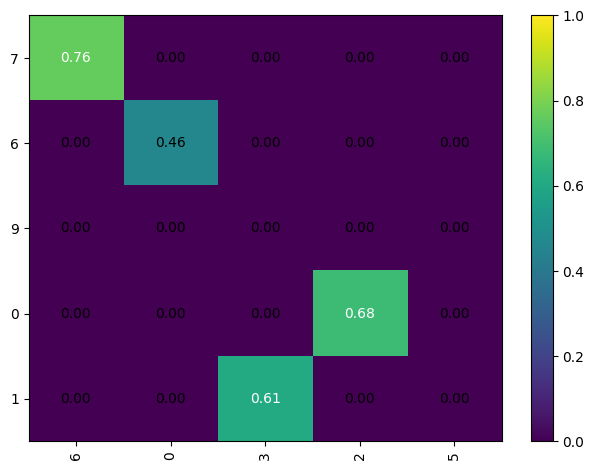

In [17]:
Q = community_jaccard_matrix_selected("SCHIZOPHRENIA","BIPOLAR", top = 5, show_plot = True)

In [16]:
jaccard_scores = []
l = len(LIST_OF_DISEASES)
dsm = np.zeros([l,l])
np.fill_diagonal(dsm, 1)
for i,j in combinations(range(l), 2):
    d1,d2 = LIST_OF_DISEASES[i],LIST_OF_DISEASES[j]
    J = community_jaccard_matrix_selected(d1,d2,show_plot = False, selected = True)
    mean_best_jaccard = (J.max(axis=1).sum() + J.max(axis=0).sum()) / (J.shape[0] + J.shape[1])
    dsm[i,j] = mean_best_jaccard
    jaccard_scores.append((mean_best_jaccard,i,j))
    
# symmetrize
dsm = dsm + dsm.T
np.fill_diagonal(dsm, 1)

print(dsm)

[[1.         0.50438131 0.24869742 0.34513799 0.47041254 0.34013445]
 [0.50438131 1.         0.44566208 0.38776313 0.37976569 0.23180826]
 [0.24869742 0.44566208 1.         0.22918274 0.28508717 0.21851155]
 [0.34513799 0.38776313 0.22918274 1.         0.32269973 0.30547204]
 [0.47041254 0.37976569 0.28508717 0.32269973 1.         0.33360407]
 [0.34013445 0.23180826 0.21851155 0.30547204 0.33360407 1.        ]]


In [17]:
jaccard_scores = sorted(jaccard_scores, key = lambda x: x[0], reverse = True)
jaccard_scores

[(0.5043813087673588, 0, 1),
 (0.47041254453423464, 0, 4),
 (0.44566208193655427, 1, 2),
 (0.38776313327702294, 1, 3),
 (0.3797656906338881, 1, 4),
 (0.34513798811570584, 0, 3),
 (0.34013445193567254, 0, 5),
 (0.33360406765920586, 4, 5),
 (0.3226997277102011, 3, 4),
 (0.3054720420321937, 3, 5),
 (0.2850871749644477, 2, 4),
 (0.24869742300117662, 0, 2),
 (0.23180826459105558, 1, 5),
 (0.2291827375022772, 2, 3),
 (0.2185115534869774, 2, 5)]

In [18]:
jaccard_scores_disease = [(LIST_OF_DISEASES[i],LIST_OF_DISEASES[j],s) for s,i,j in jaccard_scores]
jaccard_scores_disease

[('BIPOLAR', 'SCHIZOPHRENIA', 0.5043813087673588),
 ('BIPOLAR', 'DIABETES', 0.47041254453423464),
 ('SCHIZOPHRENIA', 'LEUKEMIA', 0.44566208193655427),
 ('SCHIZOPHRENIA', 'PARKINSON', 0.38776313327702294),
 ('SCHIZOPHRENIA', 'DIABETES', 0.3797656906338881),
 ('BIPOLAR', 'PARKINSON', 0.34513798811570584),
 ('BIPOLAR', 'BREASTCANCER', 0.34013445193567254),
 ('DIABETES', 'BREASTCANCER', 0.33360406765920586),
 ('PARKINSON', 'DIABETES', 0.3226997277102011),
 ('PARKINSON', 'BREASTCANCER', 0.3054720420321937),
 ('LEUKEMIA', 'DIABETES', 0.2850871749644477),
 ('BIPOLAR', 'LEUKEMIA', 0.24869742300117662),
 ('SCHIZOPHRENIA', 'BREASTCANCER', 0.23180826459105558),
 ('LEUKEMIA', 'PARKINSON', 0.2291827375022772),
 ('LEUKEMIA', 'BREASTCANCER', 0.2185115534869774)]

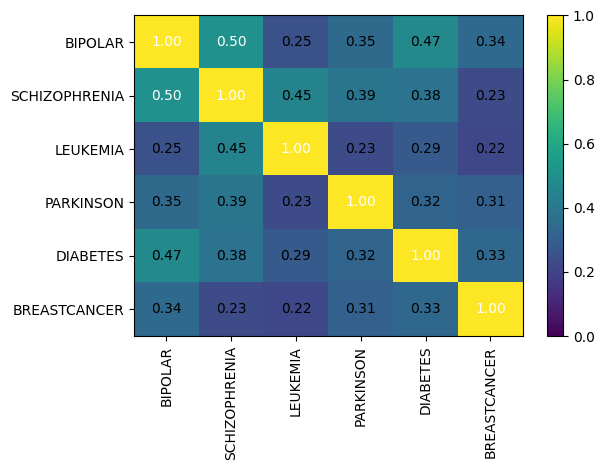

In [22]:
plot_heatmap(
    dsm, 
    row_labels=LIST_OF_DISEASES,
    col_labels=LIST_OF_DISEASES,
    vmin=0, 
    vmax=1,
    save_path= "../../Graphs/disease_similarity_heatmap.png"
)
